# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** Track A: Standard Analysis Project

**Group members:** 

- Victor Bjerggaard Thøstesen
- Nikolai Mose Sannerum  
- Frederik Hansen Baattrup  

**Dataset:** 

During the project we look at game statistics for Premier league matches since 2005. The datasets from 2003/2004 and 2004/2005 seasons are disregarded due to reading issues. 

Some features of the full data is beforehand merged into the file named "Master file.csv". This master file contains the features: "HomeTeam", "AwayTeam", "Full Time Result (FTR)", "Referee", "Full Time Home Goal (FTHG)", "Full Time Away Goal (FTAG)", "Home Shots (HS)", "Away Shots (AS)", "Home Shots On Target (HST)", "Away Shots On Target (AST)", "Home Fouls (HF)", "Away Fouls (AF)", "Home Corner (HC)", "Away Corner (AC)", "Home Yellow (HY)", "Away Yellow (Ay)", "Home Red (HR)", "Away Red (AR)", "Average Home Win Odds (AvgH)", "Average Draw Odds (AvgD)", "Average Away Win Odds (AvgA)", "Date" and "Season".

**Initial task description (Module 1 perspective):**

For the first part of the project we want to analyze our dataset using clustering. Our tentative analysis goal is to pick out a set of features from the dataset which can be meaningfully clustered and compared to a ground truth. First we apply unsupervised clustering to group football matches using in game statistics. The chosen features will be combined and transformed in order to reduce dimensions and make the matches more comparable. Outcome-related variables FTHG, FTAG, FTR, HTR and odds are excluded from clustering to prevent data leak and reserved for evaluation. After normalizing the numeric features, clustering algorithms are applied to identify match groupings. The FTR column serves as ground truth to assess alignment between clusters and actual outcomes (home win, away win, draw). Cluster evaluation metrics includes contingency tables and cluster purity measurements.


## 0. Reproducibility and Setup

In [1]:
import sys
print(sys.version)

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pyclustering.cluster.clique import clique, clique_visualizer
from tqdm import tqdm
from scipy.spatial.distance import cdist
from sklearn.cluster import DBSCAN, KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.6.3.2)]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Source: https://www.football-data.co.uk/englandm.php?fbclid=IwY2xjawQVBq9leHRuA2FlbQIxMABicmlkETBhSDJ4V01maU9aZVJ1dkNsc3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHr9Bnmq21fRPvCUMfkcBIu9edZEMLrEi-QTbB8sBlRDK8vETlRUAA3XgndZg_aem_OCN-0ddvAe0Fob_1GlxMdg

- Number of instances: 7860
- Number of features / entities: 23
- Missing values: No missing values after preprocessing. However when the seasons were combined we used only the average odds (provided by different websites for different seasons).


In [2]:


# --- Data Extraction Function ---
# Here define a function to extract the chosen relevant data features from the raw CSV files.
# This function will look for the average odds columns and handle cases where they might be missing.

def extract_data(df, filename):
    """
    Extracts average in game features and home/draw/away odds from CSV file.
    Prefers BbAvH/D/A, otherwise falls back to AvgH/D/A.
    Adds season column extracted from filename.

    parameters:
    df: DataFrame containing the raw data from the CSV file.
    filename: The name of the CSV file, used to extract the season information.

    return: A DataFrame with the extracted features and season information, or None if required columns are missing.

    """

    primary_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "BbAvH", "BbAvD", "BbAvA", 'Date']
    fallback_cols = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                  'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']

    season = os.path.splitext(filename)[0]

    # Trying to find Betbrain columns first
    if all(col in df.columns for col in primary_cols):
        result = df[primary_cols].copy()
        result.columns = ['HomeTeam', 'AwayTeam', 'FTR', 'Referee', 'FTHG', 
                            'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                            'HC', 'AC', 'HY', 'AY', 'HR', 'AR', "AvgH", "AvgD", "AvgA", 'Date']
        print(f'Found primary columns: BbAvH, BbAvD, BbAvA for {filename}')

    # Else trying to find fallback columns
    elif all(col in df.columns for col in fallback_cols):
        result = df[fallback_cols].copy()
        print(f'Using fallback columns: AvgH, AvgD, AvgA for {filename}')

    # If neither set of columns is found, print a warning and return None
    else:
        print(f"⚠ Warning: Required odds columns not found in {filename}")
        return None

    # Add season column
    result["Season"] = season
    
    return result



In [7]:
# --- User settings begin ---
data_folder = "Data" #Define the folder where the raw CSV files are located.
# --- User settings end ---

new_data = []

for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        path = os.path.join(data_folder, file)
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"⚠ Error reading {file}: {e}")
            continue

        extracted = extract_data(df, file)

        if extracted is not None:
            new_data.append(extracted)

# Combine everything into one dataframe
final_df = pd.concat(new_data, ignore_index=True)

Found primary columns: BbAvH, BbAvD, BbAvA for 20072008premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20112012premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20132014premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20242025premierleague.csv
⚠ Error reading 20042005premierleague.csv: 'utf-8' codec can't decode byte 0xa0 in position 75614: invalid start byte
Using fallback columns: AvgH, AvgD, AvgA for 20202021premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20192020premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20082009premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20062007premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20152016premierleague.csv
Using fallback columns: AvgH, AvgD, AvgA for 20222023premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20102011premierleague.csv
Found primary columns: BbAvH, BbAvD, BbAvA for 20092010premierleague.csv
Found primary 

In [4]:
print(f"\n Final dataset:")
final_df = final_df.dropna(subset=["HomeTeam", "AwayTeam"]) # 2014/2015 season has a row of NaN that is removed here
final_df.head()
final_df


 Final dataset:


,HomeTeam,AwayTeam,FTR,Referee,FTHG,FTAG,HS,AS,HST,AST,...,AC,HY,AY,HR,AR,AvgH,AvgD,AvgA,Date,Season
0,Aston Villa,Liverpool,A,M Riley,1.0,2.0,10.0,17.0,6.0,7.0,...,2.0,4.0,2.0,0.0,0.0,3.67,3.23,1.95,11/08/07,20072008premierleague
1,Bolton,Newcastle,A,C Foy,1.0,3.0,13.0,7.0,9.0,5.0,...,3.0,1.0,1.0,0.0,0.0,2.41,3.18,2.80,11/08/07,20072008premierleague
2,Derby,Portsmouth,D,M Dean,2.0,2.0,12.0,12.0,5.0,6.0,...,6.0,1.0,2.0,0.0,0.0,2.85,3.19,2.38,11/08/07,20072008premierleague
3,Everton,Wigan,H,M Clattenburg,2.0,1.0,12.0,14.0,8.0,4.0,...,2.0,0.0,0.0,0.0,0.0,1.66,3.45,5.25,11/08/07,20072008premierleague
4,Middlesbrough,Blackburn,A,A Marriner,1.0,2.0,10.0,4.0,6.0,4.0,...,3.0,3.0,4.0,0.0,0.0,2.41,3.18,2.81,11/08/07,20072008premierleague
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7855,Hull,Man United,D,L Probert,0.0,0.0,16.0,7.0,6.0,1.0,...,1.0,2.0,2.0,0.0,1.0,3.14,3.55,2.21,24/05/15,20142015premierleague
7856,Leicester,QPR,H,M Oliver,5.0,1.0,22.0,18.0,7.0,2.0,...,6.0,0.0,0.0,0.0,0.0,1.56,4.21,5.71,24/05/15,20142015premierleague
7857,Man City,Southampton,H,C Foy,2.0,0.0,15.0,13.0,6.0,4.0,...,4.0,1.0,1.0,0.0,0.0,1.56,4.27,5.61,24/05/15,20142015premierleague
7858,Newcastle,West Ham,H,M Atkinson,2.0,0.0,17.0,4.0,4.0,1.0,...,3.0,2.0,1.0,0.0,0.0,1.77,3.84,4.42,24/05/15,20142015premierleague


In [8]:
def encode_results(results):
    """
    Endcoding of results
    1: HOME WIN, -1: AWAY WIN, 0: DRAW

    parameters:
    results (list of dicts): results to encode 

    returns:
    encoding (numpy array): encoded results
    """
    encoding = np.zeros(len(results)) # Initialize encoding array

    for i in range(len(results)):
        if results[i] == "H":
            encoding[i] = 1 # Home win
        elif results[i] == "A":
            encoding[i] = -1 # Away win
        else:
            encoding[i] = 0 # Draw
    return encoding
data = final_df.copy()
ground_truth = encode_results(data['FTR'])
data = pd.get_dummies(data, columns=['HomeTeam', 'AwayTeam', 'Referee']) # One-Hot encode string features
print("Amount of home wins: ", np.sum(ground_truth == 1))
print("Amount of away wins: ", np.sum(ground_truth == -1))
print("Amount of draws: ", np.sum(ground_truth == 0))

Amount of home wins:  3586
Amount of away wins:  2368
Amount of draws:  1907


### In the following cells new features are engineered and normalized.

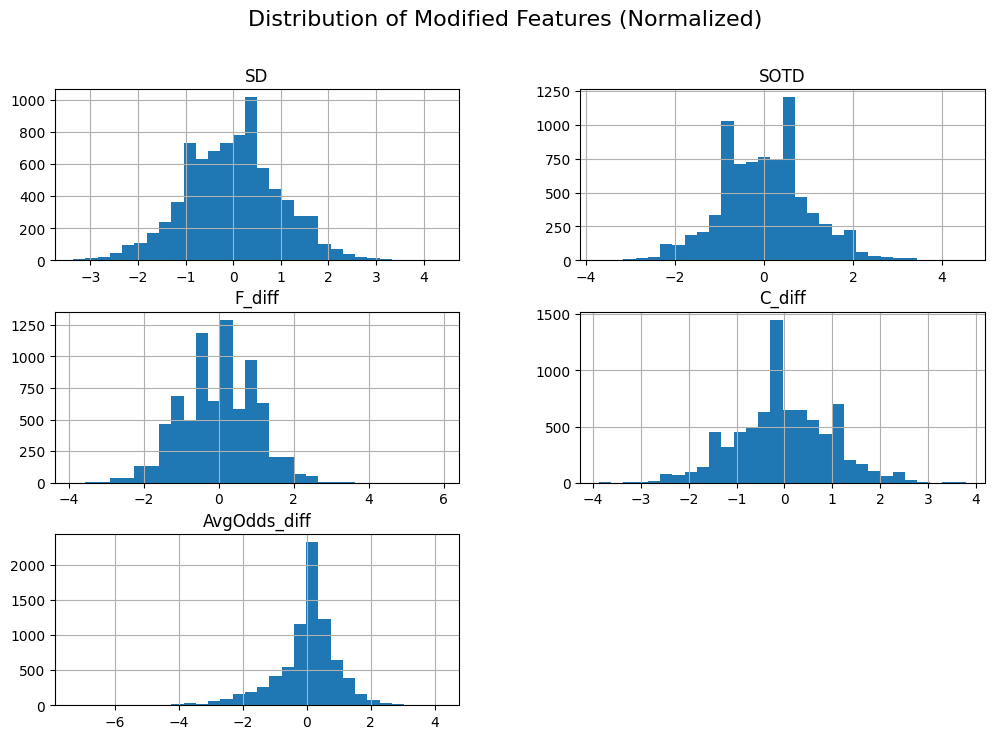

In [ ]:
# --- Creating new features by calculating the difference between home and away statistics (Positive means home team have more) ---
modified_stats = pd.DataFrame({'SD': data['HS'] - data['AS'],
                            'SOTD': data['HST'] - data['AST'],
                            'F_diff': data['HF'] - data['AF'],
                            'C_diff': data['HC'] - data['AC'],
                            #'YC_diff': data['HY'] - data['AY'],
                            'AvgOdds_diff': data['AvgH'] - data['AvgA'],
                            #'RC_diff': data['HR'] - data['AR']
                            }) 

# --- Normalize the new features with average and standard deviation ---
modified_stats = (modified_stats - modified_stats.mean()) / modified_stats.std()

#print(modified_stats['SD'].mean(), modified_stats['SD'].std())

# -- Plot as histogram to see the distribution of the new features ---
modified_stats.hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribution of Modified Features (Normalized)', fontsize=16)
plt.show()

### Exploratory Data Analysis
- Basic statistics
- Distributions
- Sparsity / density

### Cleaning & Transformations
- Handling missing values
- Feature engineering
- Graph construction (if Checkpoint 2)

Justify design decisions.

## 2. Module 1 — Vector-Space Analysis

### 2.1 Vector Representation

Explain your feature construction and distance measure here.

In [ ]:
# Construct vector representation
X = None  # Replace with actual feature matrix

### 2.2 Clustering Method

In [ ]:
# Implement clustering algorithm here
labels = None

## 3. Module 2 — Graph-Based Analysis

In [ ]:
import networkx as nx

# Build graph
G = nx.Graph()

ModuleNotFoundError: No module named 'networkx'

## 4. Module 3 — Pattern / Text Mining

In [ ]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
